In [1]:
import scanpy as sc
import squidpy as sq
import os
from sklearn.metrics import adjusted_rand_score,normalized_mutual_info_score
import matplotlib.pyplot as plt


/home/ec2-user/miniforge3/envs/spatial/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sc.settings.verbosity = 3
processed_dir = os.path.expanduser("../data/processed")
sc.settings.figdir = "../results/figures"
figure_dir = "../results/figures"

In [3]:
adata = sc.read_h5ad(os.path.expanduser("../data/processed/01_qc.h5ad"))

In [4]:
# save row counts for deconvolution
adata.layers["counts"] = adata.X.copy()

In [5]:
# normalization
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.raw = adata

normalizing counts per cell
    finished (0:00:02)


In [6]:
# HVG
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
    n_top_genes=3000,
    layer="counts" 
)

adata.var['highly_variable'].sum()

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


np.int64(3000)

In [7]:
# PCA
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
sc.pp.scale(adata_hvg)
sc.tl.pca(adata_hvg, n_comps=50)

adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"]
adata.uns["pca"] = adata_hvg.uns["pca"]

computing PCA
    with n_comps=50


/home/ec2-user/miniforge3/envs/spatial/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


    finished (0:00:01)


/tmp/ipykernel_76656/505297048.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True,


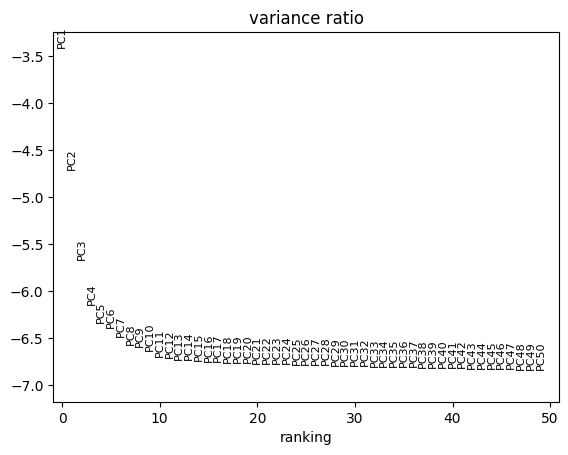

In [8]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True,
                         save="_elbow.png")

In [9]:
# kNN 
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=17)

computing neighbors
    using 'X_pca' with n_pcs = 17
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:08)


In [10]:
sq.gr.spatial_neighbors(adata, coord_type="grid", n_neighs=6)

INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`


In [11]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:04)


In [12]:
# this analysis is for benchmarking expression clustering and spatial clustering methods, 
# so pick leiden res by grount truth (k =7)
for res in [0.3, 0.5, 0.55, 0.6, 0.65, 0.7]:
    sc.tl.leiden(adata, resolution=res, key_added=f"leiden_{res}")
    n_clusters = adata.obs[f"leiden_{res}"].nunique()
    print(f"resolution={res}: {n_clusters} clusters")

running Leiden clustering


/tmp/ipykernel_76656/275583401.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f"leiden_{res}")


    finished: found 4 clusters and added
    'leiden_0.3', the cluster labels (adata.obs, categorical) (0:00:01)
resolution=0.3: 4 clusters
running Leiden clustering


/tmp/ipykernel_76656/275583401.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f"leiden_{res}")


    finished: found 6 clusters and added
    'leiden_0.5', the cluster labels (adata.obs, categorical) (0:00:00)
resolution=0.5: 6 clusters
running Leiden clustering


...

    finished: found 7 clusters and added
    'leiden_0.6', the cluster labels (adata.obs, categorical) (0:00:01)
resolution=0.6: 7 clusters
running Leiden clustering


/tmp/ipykernel_76656/275583401.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f"leiden_{res}")


    finished: found 8 clusters and added
    'leiden_0.65', the cluster labels (adata.obs, categorical) (0:00:01)
resolution=0.65: 8 clusters
running Leiden clustering


/tmp/ipykernel_76656/275583401.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f"leiden_{res}")


    finished: found 8 clusters and added
    'leiden_0.7', the cluster labels (adata.obs, categorical) (0:00:00)
resolution=0.7: 8 clusters


In [13]:
for res in [0.58, 0.6, 0.62]:
    sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')
    n = adata.obs[f'leiden_{res}'].nunique()
    print(f'resolution={res}: {n} clusters')

running Leiden clustering


/tmp/ipykernel_76656/1141763113.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')


    finished: found 6 clusters and added
    'leiden_0.58', the cluster labels (adata.obs, categorical) (0:00:01)
resolution=0.58: 6 clusters
running Leiden clustering


/tmp/ipykernel_76656/1141763113.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')


    finished: found 7 clusters and added
    'leiden_0.6', the cluster labels (adata.obs, categorical) (0:00:01)
resolution=0.6: 7 clusters
running Leiden clustering


/tmp/ipykernel_76656/1141763113.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')


    finished: found 7 clusters and added
    'leiden_0.62', the cluster labels (adata.obs, categorical) (0:00:01)
resolution=0.62: 7 clusters


In [14]:
mask = adata.obs['ground_truth'].notna()
for res in [0.6, 0.62]:
    key = f'leiden_{res}'
    if adata.obs[key].nunique() == 7:
        ari = adjusted_rand_score(adata.obs.loc[mask, 'ground_truth'], adata.obs.loc[mask, key])
        print(f'resolution={res}: ARI={ari:.4f}')

resolution=0.6: ARI=0.3806
resolution=0.62: ARI=0.3882


In [15]:
best_res = 0.62
adata.obs["leiden"] = adata.obs[f"leiden_{best_res}"]

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# UMAP colored by ground truth
sc.pl.umap(adata, color="ground_truth", ax=axes[0, 0], show=False,
           title="UMAP - Ground Truth")

# UMAP colored by Leiden
sc.pl.umap(adata, color="leiden", ax=axes[0, 1], show=False,
           title=f"UMAP - Leiden (res={best_res})")

# spatial - ground truth
sc.pl.spatial(adata, color="ground_truth", ax=axes[1, 0], show=False,
              title="Spatial - Ground Truth", spot_size=100)

# spatial - Leiden
sc.pl.spatial(adata, color="leiden", ax=axes[1, 1], show=False,
              title=f"Spatial - Leiden (res={best_res})", spot_size=100)

plt.tight_layout()
plt.savefig(os.path.join(figure_dir, "preprocessing_panel.png"), dpi=200, bbox_inches='tight')
plt.close()

/tmp/ipykernel_76656/2411446754.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="ground_truth", ax=axes[1, 0], show=False,
/tmp/ipykernel_76656/2411446754.py:16: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="leiden", ax=axes[1, 1], show=False,


In [17]:
# compute baseline ari
ari = adjusted_rand_score(adata.obs["ground_truth"], adata.obs["leiden"])
nmi = normalized_mutual_info_score(adata.obs["ground_truth"], adata.obs["leiden"])
print(f"Leiden baseline - ARI: {ari:.4f}, NMI: {nmi:.4f}")

Leiden baseline - ARI: 0.3882, NMI: 0.5009


In [18]:
adata.write(os.path.join(processed_dir, "02_preprocessed.h5ad"))